In [ ]:
# Trains the regularised LSTM on calm 2010–2019 data, evaluates it across the six stress scenarios, and runs the lookback contamination test 
# with the dependence-corrected bootstrap. 
# Produces Tables 3–7 and Figures 1, 4, 6, 7. Sections 3.6–3.8 and 4.2–4.5. This is the core notebook

In [8]:
'''Setup and reproducibility

Imports the LSTM stack (Keras), the metrics (raw and balanced accuracy), the
class-weight helper, and the S&P 500 data loader. All sources of randomness are
then pinned to a single seed (42), Python, NumPy, TensorFlow, hash ordering, and
deterministic ops, so every run of this notebook reproduces the same trained model
and the same results.

'''


import os
import sys
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader



# REPRODUCIBILITY - SET ONCE, AT THE VERY TOP

SEED = 42  # Use the same seed throughout

# 1. Python's random module
random.seed(SEED)

# 2. NumPy
np.random.seed(SEED)

# 3. TensorFlow
tf.random.set_seed(SEED)

# 4. Environment variable for Python's hash randomization
os.environ['PYTHONHASHSEED'] = str(SEED)

# 5. CRITICAL: Disable GPU nondeterminism
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# 6. Enable TensorFlow determinism
tf.config.experimental.enable_op_determinism()

print("="*70)
print("LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING")
print(f"Random Seed: {SEED}")
print("="*70)

LSTM VOLATILITY PREDICTION WITH MONTE CARLO STRESS TESTING
Random Seed: 42


In [9]:
class PathManager:
    """Save and load Monte Carlo paths for reproducibility."""

    def __init__(self, save_dir="../data/simulated"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def _filename(self, scenario_name):
        # single source of truth for the path, so save/load/exists always agree
        return f"{self.save_dir}/{scenario_name}.npy"

    def save_paths(self, paths, scenario_name):
        filename = self._filename(scenario_name)
        np.save(filename, paths)
        print(f"Saved {scenario_name} paths to {filename}")

    def load_paths(self, scenario_name):
        filename = self._filename(scenario_name)
        if os.path.exists(filename):
            paths = np.load(filename)
            print(f"Loaded {scenario_name} paths from {filename}")
            return paths
        print(f"{scenario_name} paths not found at {filename}")
        return None

    def paths_exist(self, scenario_name):
        return os.path.exists(self._filename(scenario_name))

In [10]:
'''
It loads the full S&P 500 series through the data loader, takes the percent-scale log_returns, drops the leading NaN, 
and slices the calm 2010–2019 window, the only data the LSTM is trained on.print("\n" + "="*60)

'''


print("PART 1: DATA LOADING AND PREPARATION")


# Load S&P 500 data (broad range; we train only on the calm 2010-2019 slice)
loader = SP500DataLoader(start_year=1997, end_year=2022)
df = loader.load_all()

# Percent-scale log returns; take the pre-COVID training window (drop leading NaN)
all_returns = df['log_returns'].dropna()
train_returns = all_returns['2010':'2019'].values   # calm regime the LSTM trains on

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")
print(f"train_returns std: {train_returns.std():.4f}   (expect ~0.9, percent scale)")

PART 1: DATA LOADING AND PREPARATION
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31
train_returns std: 0.9319   (expect ~0.9, percent scale)


In [11]:

'''
Sequence and label construction

Volatility is not directly observable, so it is proxied by the absolute return
$|r_t|$: a larger absolute move indicates a more volatile day, independent of
direction.

For each target day $t$, one training example is formed:

Input feature window (the 60 returns preceding $t$, excluding $t$ itself):

$$
X_t = \big[\, r_{t-60},\; r_{t-59},\; \dots,\; r_{t-1} \,\big] \in \mathbb{R}^{60}
$$

Binary volatility label (is day $t$ more turbulent than its recent norm?):

$$
y_t =
\begin{cases}
1 \ (\text{HIGH}) & \text{if } |r_t| > \dfrac{1}{20}\displaystyle\sum_{k=1}^{20} |r_{t-k}| \\[3mm]
0 \ (\text{LOW}) & \text{otherwise}
\end{cases}
$$

where the threshold $\frac{1}{20}\sum_{k=1}^{20}|r_{t-k}|$ is the mean absolute
return over the 20 trading days preceding $t$.

No look-ahead. The target day $t$ is excluded from $X_t$, and the label
threshold uses only days strictly before $t$. The model therefore never observes
the return it is asked to classify.

Window sizes. The 60-day lookback ($\approx$ one quarter) follows the optimal
window of Yachou et al. (2026); the 20-day volatility window ($\approx$ one month)
sets the recent baseline.

Relative construction. The label is defined relative to a moving 20-day
baseline rather than a fixed absolute threshold. When the baseline is itself
elevated (as in a crisis), a genuinely large move may not exceed it and is
labelled LOW, this relative definition is what the lookback contamination test in
Section 4.5 exploits.

'''

def create_volatility_sequences(data, lookback=60, vol_window=20):
    """
    Create sequences and volatility labels.
    Following Yachou et al. (2026): 60-day lookback window
    
    Label: 1 if next day's volatility > recent average volatility
    """
    X, y = [], []
    
    for i in range(lookback, len(data) - 1):
        # Input: last 'lookback' returns
        X.append(data[i-lookback:i])
        
        # Calculate recent average volatility (last 'vol_window' days)
        recent_vol = np.abs(data[i-vol_window:i]).mean()
        
        # Next day volatility
        next_vol = np.abs(data[i])
        
        # Label: 1 if next volatility > recent average, else 0
        y.append(1 if next_vol > recent_vol else 0)
    
    return np.array(X), np.array(y)


#60-day input window ≈ one quarter of trading, enough context for the LSTM to read the recent pattern; it also matches the optimal window Yachou et al. (2026) found.
#20-day volatility window ≈ one trading month, a recent baseline for "normal" volatility: long enough to be stable, short enough to adapt.
lookback = 60
vol_window = 20

X, y = create_volatility_sequences(train_returns, lookback, vol_window)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: HIGH volatility={y.sum()}, LOW volatility={len(y)-y.sum()}")
print(f"Proportion HIGH: {y.sum()/len(y)*100:.1f}%")


X shape: (2455, 60)
y shape: (2455,)
Class balance: HIGH volatility=975, LOW volatility=1480
Proportion HIGH: 39.7%


<>:1: SyntaxWarning: invalid escape sequence '\,'
<>:1: SyntaxWarning: invalid escape sequence '\,'
/var/folders/x8/_mq2nwzn4x5_6w2mj59szrb40000gn/T/ipykernel_16261/1282557898.py:1: SyntaxWarning: invalid escape sequence '\,'
  '''


In [13]:
'''
 Train/validation split and feature scaling

The examples are split **chronologically** (80% train, 20% validation, `shuffle=False`),
so the validation set is the most recent period and no future information leaks into
training. A `StandardScaler` is then fit **only** on the training windows and applied
unchanged to validation:

$$
\tilde{x} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

Fitting on training data alone defines "normal" by the calm 2010–2019 regime, and the
same scaler is later reused on the stress paths so a crisis return is measured against
the calm baseline. Inputs are finally reshaped to $(\text{samples}, 60, 1)$, the LSTM's
required 3D format (60 timesteps, one feature per step).

'''

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features (critical for LSTM convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, lookback)).reshape(-1, lookback, 1)
X_val_scaled = scaler.transform(X_val.reshape(-1, lookback)).reshape(-1, lookback, 1)

print(f"\nTrain shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")



Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
/var/folders/x8/_mq2nwzn4x5_6w2mj59szrb40000gn/T/ipykernel_16261/1019831021.py:1: SyntaxWarning: invalid escape sequence '\m'
  '''


In [14]:
''' Balanced class weights

The data is imbalanced (~60% LOW, ~40% HIGH). Class weights
$w_k = N_{\text{train}} / (K \cdot N_k)$ up-weight the minority HIGH class so that
missing a high-volatility day is penalised more heavily during training. This gives
about 0.839 (LOW) and 1.237 (HIGH).

'''

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, class_weights)}

print(f"\nClass distribution: LOW={np.sum(y_train==0)}, HIGH={np.sum(y_train==1)}")
print(f"Class weights: {class_weight_dict}")




Class distribution: LOW=1187, HIGH=777
Class weights: {0: 0.827295703454086, 1: 1.263835263835264}


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x8/_mq2nwzn4x5_6w2mj59szrb40000gn/T/ipykernel_16261/1234329079.py:1: SyntaxWarning: invalid escape sequence '\c'
  ''' Balanced class weights


In [15]:
'''
 LSTM architecture

A compact classifier: one LSTM(32) reads the 60-day return window into a single
hidden state, dropout (0.2) regularises it, a Dense(16, ReLU) extracts non-linear
features and a Dense(1, sigmoid) outputs the probability of a
HIGH-volatility day. Trained with Adam (lr 0.0005) and binary cross-entropy. Total
trainable parameters: 4,897.
'''


def build_volatility_lstm(lookback=60, lstm_units=32, dropout_rate=0.2):
    """
    Build LSTM model for volatility prediction.
    Architecture inspired by Yachou et al. (2026)
    """
    model = Sequential([
        LSTM(lstm_units, return_sequences=False, input_shape=(lookback, 1)),  # ← FIXED
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_volatility_lstm(lookback=lookback, lstm_units=32, dropout_rate=0.2)
model.summary()



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
''' Training the model

Trains the LSTM with Adam (lr 0.0005), batch size 32, up to 100 epochs, and balanced
class weights. Two callbacks adapt the run: EarlyStopping (patience 10) restores the
best-epoch weights, and ReduceLROnPlateau (factor 0.5, patience 5) lowers the learning
rate when validation loss stalls.
'''


early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1  # a live progress bar for each epoch
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


print("PART 6: TRAINING THE MODEL")


history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n Training complete!")



PART 6: TRAINING THE MODEL
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5087 - loss: 0.6866 - val_accuracy: 0.5988 - val_loss: 0.6837 - learning_rate: 5.0000e-04
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5733 - loss: 0.6798 - val_accuracy: 0.6151 - val_loss: 0.6784 - learning_rate: 5.0000e-04
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5973 - loss: 0.6730 - val_accuracy: 0.6436 - val_loss: 0.6632 - learning_rate: 5.0000e-04
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6100 - loss: 0.6653 - val_accuracy: 0.6517 - val_loss: 0.6477 - learning_rate: 5.0000e-04
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6100 - loss: 0.6634 - val_accuracy: 0.6558 - val_loss: 0.6384 - learning_rate: 5.0000e-04
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.6059 - loss: 0.6619 - val_accuracy: 0.6558 - val_loss: 0.6386 - learning_rate: 5.0000e-04
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━

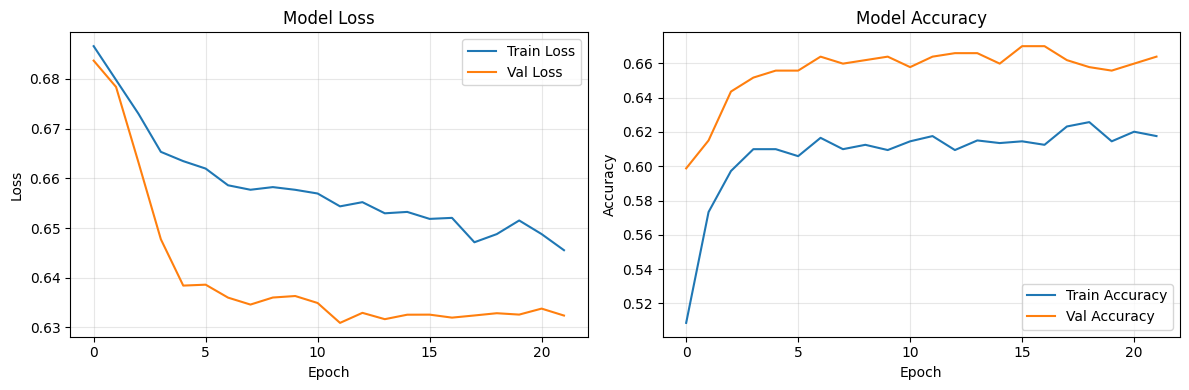

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/lstm_training_history.png', dpi=150)
plt.show()

In [18]:
val_loss, val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.2%}")



Validation Loss: 0.6309
Validation Accuracy: 66.40%


In [19]:
''' Loading the Monte Carlo stress paths

Loads the six scenario arrays (`mc_returns_*.npy`) generated earlier, and reuses the
training scaler (fit on 2010-2019) to transform them, so the stress paths are
measured against the same calm baseline the model was trained on, with no refitting.
'''


print("\n" + "="*60)
print("PART 9: LOADING MONTE CARLO PATHS")
print("="*60)

data_path = '../data/simulated/'

normal_paths = np.load(os.path.join(data_path, 'mc_returns_normal.npy'))
crisis_2008_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_2008.npy'))
crisis_covid_paths = np.load(os.path.join(data_path, 'mc_returns_crisis_covid.npy'))
synthetic_paths = np.load(os.path.join(data_path, 'mc_returns_synthetic_extreme.npy'))
squeeze_paths = np.load(os.path.join(data_path, 'mc_returns_squeeze.npy'))
structural_break_paths = np.load(os.path.join(data_path, 'mc_returns_structural_break.npy'))

print(f"Normal paths: {normal_paths.shape}")
print(f"2008 Crisis: {crisis_2008_paths.shape}")
print(f"COVID Crisis: {crisis_covid_paths.shape}")
print(f"Synthetic Extreme: {synthetic_paths.shape}")
print(f"Non-linear Squeeze: {squeeze_paths.shape}")
print(f"Structural Break: {structural_break_paths.shape}")

print(f"\n✅ Using original training scaler (fitted on X_train 2010-2019)")
print(f"   Scaler mean shape:  {scaler.mean_.shape}")
print(f"   Scaler scale shape: {scaler.scale_.shape}")


PART 9: LOADING MONTE CARLO PATHS
Normal paths: (10000, 252)
2008 Crisis: (10000, 252)
COVID Crisis: (10000, 252)
Synthetic Extreme: (10000, 252)
Non-linear Squeeze: (10000, 252)
Structural Break: (10000, 252)

✅ Using original training scaler (fitted on X_train 2010-2019)
   Scaler mean shape:  (60,)
   Scaler scale shape: (60,)


In [20]:

# SHows the truth label per path: HIGH (1) if the final day's
# |return| exceeds the mean |return| of the prior 20 days, else LOW (0)

def get_volatility_labels_mc(paths, lookback=60, vol_window=20):
    """True labels: target day is the LAST day; baseline is the 20 days before it."""
    recent_vol = np.abs(paths[:, -(vol_window+1):-1]).mean(axis=1)   # 20 days: T-20..T-1
    next_vol   = np.abs(paths[:, -1])                                # target: day T
    return (next_vol > recent_vol).astype(int)


#Feeds the 60 days before the target (excluding the target) through the LSTM,
#scaled with the training scaler, in batches of 500; returns the HIGH probability per path.

def predict_on_paths(model, paths, lookback=60, batch_size=500):
    """Features are the 60 days BEFORE the target day — target excluded (no leak)."""
    all_probs = []
    for i in range(0, paths.shape[0], batch_size):
        batch = paths[i:i+batch_size]
        features = batch[:, -(lookback+1):-1]        # days T-60..T-1, EXCLUDES day T
        features_scaled = scaler.transform(features).reshape(-1, lookback, 1)
        probs = model.predict(features_scaled, verbose=0)
        all_probs.extend(probs.flatten())
    return np.array(all_probs)

#Thresholds probabilities at 0.5 and returns raw directional accuracy (%).
def calculate_accuracy(predictions, true_labels):
    """Calculate directional accuracy."""
    pred_labels = (predictions > 0.5).astype(int)
    return (pred_labels == true_labels).mean() * 100

In [21]:

print("PART 12: STRESS TESTING ON MONTE CARLO PATHS")


results = {}

# 1. Normal Scenario
print("\n1. Normal scenario...")
true_labels_normal = get_volatility_labels_mc(normal_paths)
probs_normal = predict_on_paths(model, normal_paths)
acc_normal = calculate_accuracy(probs_normal, true_labels_normal)
results['Normal'] = acc_normal
print(f"   ✅ Accuracy: {acc_normal:.2f}%")

# 2. 2008 Crisis
print("\n2. 2008 Crisis magnitude scenario...")
true_labels_2008 = get_volatility_labels_mc(crisis_2008_paths)
probs_2008 = predict_on_paths(model, crisis_2008_paths)
acc_2008 = calculate_accuracy(probs_2008, true_labels_2008)
results['2008 Crisis Magnitude'] = acc_2008
print(f"   ✅ Accuracy: {acc_2008:.2f}%")

# 3. COVID Crisis
print("\n3. COVID Crisis magnitude scenario...")
true_labels_covid = get_volatility_labels_mc(crisis_covid_paths)
probs_covid = predict_on_paths(model, crisis_covid_paths)
acc_covid = calculate_accuracy(probs_covid, true_labels_covid)
results['COVID Crisis Magnitude'] = acc_covid
print(f"   ✅ Accuracy: {acc_covid:.2f}%")

# 4. Synthetic Extreme
print("\n4. Synthetic Extreme scenario...")
true_labels_synthetic = get_volatility_labels_mc(synthetic_paths)
probs_synthetic = predict_on_paths(model, synthetic_paths)
acc_synthetic = calculate_accuracy(probs_synthetic, true_labels_synthetic)
results['Synthetic Extreme'] = acc_synthetic
print(f"   ✅ Accuracy: {acc_synthetic:.2f}%")

# 5. Non-linear Squeeze
print("\n5. Non-linear Squeeze scenario...")
true_labels_squeeze = get_volatility_labels_mc(squeeze_paths)
probs_squeeze = predict_on_paths(model, squeeze_paths)
acc_squeeze = calculate_accuracy(probs_squeeze, true_labels_squeeze)
results['Non-linear Squeeze'] = acc_squeeze
print(f"   ✅ Accuracy: {acc_squeeze:.2f}%")

# 6. Structural Break
print("\n6. Structural Break scenario...")
true_labels_break = get_volatility_labels_mc(structural_break_paths)
probs_break = predict_on_paths(model, structural_break_paths)
acc_break = calculate_accuracy(probs_break, true_labels_break)
results['Structural Break'] = acc_break
print(f"   ✅ Accuracy: {acc_break:.2f}%")

PART 12: STRESS TESTING ON MONTE CARLO PATHS

1. Normal scenario...
   ✅ Accuracy: 55.37%

2. 2008 Crisis magnitude scenario...
   ✅ Accuracy: 56.43%

3. COVID Crisis magnitude scenario...
   ✅ Accuracy: 56.85%

4. Synthetic Extreme scenario...
   ✅ Accuracy: 56.48%

5. Non-linear Squeeze scenario...
   ✅ Accuracy: 56.48%

6. Structural Break scenario...
   ✅ Accuracy: 56.30%


In [22]:


#Runs the trained LSTM on all paths of each scenario and reports raw accuracy (prevalence-sensitive) and balanced accuracy (prevalence-independent).
#Saved to `results/tables/lstm_volatility_results.csv`, the source for Table 5.
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score

scenario_paths = {
    'normal':            normal_paths,
    'crisis_covid':      crisis_covid_paths,
    'crisis_2008':       crisis_2008_paths,
    'synthetic_extreme': synthetic_paths,
    'structural_break':  structural_break_paths,
    'squeeze':           squeeze_paths,
}

rows = []
for name, paths in scenario_paths.items():          # paths is a plain array here
    y_true = get_volatility_labels_mc(paths)
    y_pred = (predict_on_paths(model, paths) > 0.5).astype(int)
    rows.append({
        'Scenario':         name,
        'Raw acc (%)':      round(accuracy_score(y_true, y_pred) * 100, 2),
        'Balanced acc (%)': round(balanced_accuracy_score(y_true, y_pred) * 100, 2),
    })


results_df = pd.DataFrame(rows)

# Save to the results/tables folder (this is the source for Table 5)
out_dir = Path('../results/tables')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'lstm_volatility_results.csv'
results_df.to_csv(out_path, index=False)
print(f'Saved -> {out_path}')

print(pd.DataFrame(rows).to_string(index=False))

Saved -> ../results/tables/lstm_volatility_results.csv
         Scenario  Raw acc (%)  Balanced acc (%)
           normal        55.37             56.38
     crisis_covid        56.85             57.58
      crisis_2008        56.43             56.88
synthetic_extreme        56.48             56.79
 structural_break        56.30             56.62
          squeeze        56.48             55.61


In [23]:

#: Final results and degradation analysis

# per-scenario accuracy and compares each scenario to the Normal baseline to report the change in percentage points (degradation or improvement).

print(" FINAL RESULTS")


results_df = pd.DataFrame(list(results.items()), columns=['Scenario', 'Accuracy (%)'])
print(results_df.to_string(index=False))

# Calculate degradation from Normal
baseline = results['Normal']
print("\n" + "="*60)
print("DEGRADATION ANALYSIS")
print("="*60)
print(f"Baseline (Normal): {baseline:.2f}%")
print("-" * 40)

for scenario, acc in results.items():
    if scenario != 'Normal':
        change = acc - baseline
        if change < 0:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (DEGRADATION)")
        else:
            print(f"{scenario:20} {acc:.2f}% → Change: {change:+.2f} pp (IMPROVEMENT)")
if 'Non-linear Squeeze' in results:
    squeeze_acc = results['Non-linear Squeeze']
    if squeeze_acc < baseline:
        rel_degradation = (baseline - squeeze_acc) / baseline * 100
        print(f"\n✅ Non-linear Squeeze degradation: {rel_degradation:.1f}% relative drop")
        print(f"   Absolute: {baseline - squeeze_acc:.2f} percentage points")
    else:
        print("\n No degradation detected in Non-linear Squeeze")


 FINAL RESULTS
              Scenario  Accuracy (%)
                Normal         55.37
 2008 Crisis Magnitude         56.43
COVID Crisis Magnitude         56.85
     Synthetic Extreme         56.48
    Non-linear Squeeze         56.48
      Structural Break         56.30

DEGRADATION ANALYSIS
Baseline (Normal): 55.37%
----------------------------------------
2008 Crisis Magnitude 56.43% → Change: +1.06 pp (IMPROVEMENT)
COVID Crisis Magnitude 56.85% → Change: +1.48 pp (IMPROVEMENT)
Synthetic Extreme    56.48% → Change: +1.11 pp (IMPROVEMENT)
Non-linear Squeeze   56.48% → Change: +1.11 pp (IMPROVEMENT)
Structural Break     56.30% → Change: +0.93 pp (IMPROVEMENT)

 No degradation detected in Non-linear Squeeze


In [24]:
os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/lstm_volatility_results.csv', index=False)
model.save('../models/lstm_volatility_model.h5')

print("\n✅ Results saved to results/lstm_volatility_results.csv")
print("✅ Model saved to models/lstm_volatility_model.h5")



✅ Results saved to results/lstm_volatility_results.csv
✅ Model saved to models/lstm_volatility_model.h5


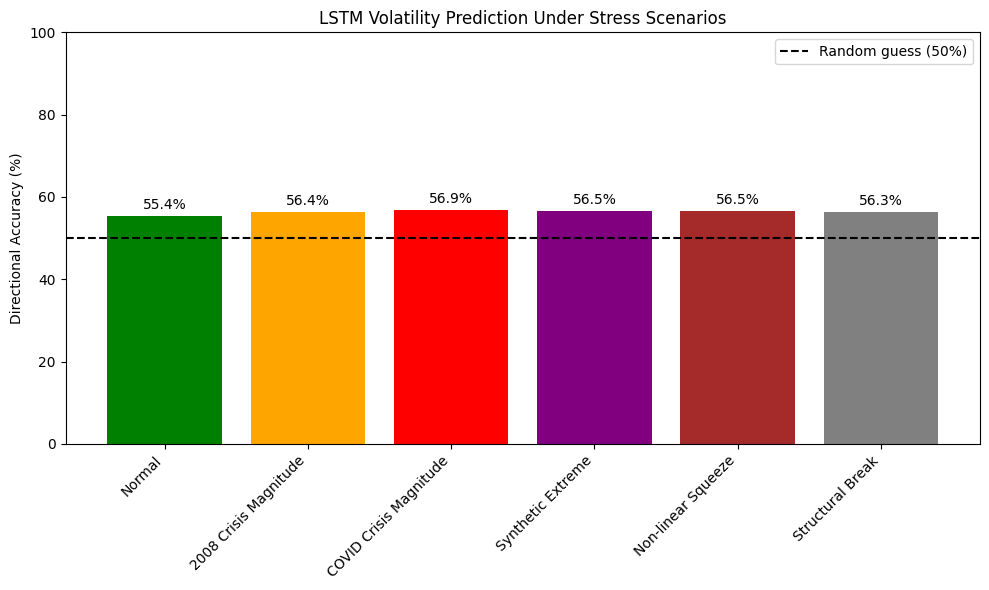


✅ LSTM VOLATILITY ANALYSIS COMPLETE


In [25]:

#Appendix A.4: Stress-test accuracy bar chart

plt.figure(figsize=(10, 6))
scenarios = list(results.keys())
accuracies = list(results.values())

colors = ['green', 'orange', 'red', 'purple', 'brown', 'gray']
bars = plt.bar(scenarios, accuracies, color=colors[:len(scenarios)])
plt.axhline(y=50, color='black', linestyle='--', label='Random guess (50%)')
plt.ylabel('Directional Accuracy (%)')
plt.title('LSTM Volatility Prediction Under Stress Scenarios')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend()

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../results/lstm_volatility_results.png', dpi=150)
plt.show()

print("\n" + "="*70)
print("✅ LSTM VOLATILITY ANALYSIS COMPLETE")
print("="*70)

Baseline (Normal): 55.37%   Bonferroni threshold: 0.0100 (0.05 / 5)

              Scenario Accuracy (%) Δ vs Normal (pp)     z p-value Cohen h Sig (Bonferroni)                                            Finding
                Normal        55.37                —     —       —       —                —                                           Baseline
 2008 Crisis Magnitude        56.43            +1.06 1.510  0.1311  0.0213               no                not significant (negligible effect)
COVID Crisis Magnitude        56.85            +1.48 2.109  0.0350  0.0298               no nominal only, fails Bonferroni (negligible effect)
     Synthetic Extreme        56.48            +1.11 1.581  0.1139  0.0224               no                not significant (negligible effect)
    Non-linear Squeeze        56.48            +1.11 1.581  0.1139  0.0224               no                not significant (negligible effect)
      Structural Break        56.30            +0.93 1.324  0.1854  0.018

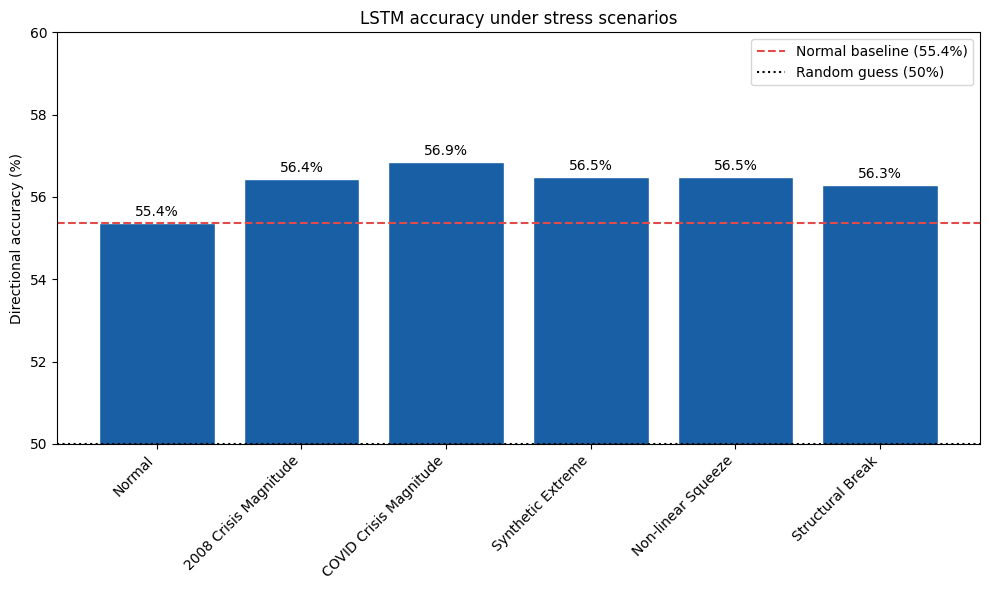

In [26]:
#Statistical significance: stress scenarios vs Normal



# Proportion z-test: each stress scenario vs Normal baseline
# H0: accuracy(scenario) == accuracy(Normal)   [two-sided]
# Reported with Bonferroni correction and Cohen's h effect size.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.stats.proportion import proportions_ztest

N_PATHS = 10_000
ALPHA   = 0.05

# Use the accuracies computed earlier, so the test can never drift from the table.
scenario_results = dict(results)                 # {'Normal': .., '2008 Crisis Magnitude': .., ...}
stress = [s for s in scenario_results if s != 'Normal']
m = len(stress)                                  # number of comparisons
alpha_bonf = ALPHA / m                           # Bonferroni-corrected threshold

baseline_acc  = scenario_results['Normal']
baseline_corr = round(baseline_acc / 100 * N_PATHS)
p1 = baseline_acc / 100

def cohen_h(pa, pb):
    return abs(2*np.arcsin(np.sqrt(pa)) - 2*np.arcsin(np.sqrt(pb)))

rows = [{
    'Scenario': 'Normal', 'Accuracy (%)': f'{baseline_acc:.2f}',
    'Δ vs Normal (pp)': '—', 'z': '—', 'p-value': '—',
    "Cohen h": '—', 'Sig (Bonferroni)': '—', 'Finding': 'Baseline',
}]

for s in stress:
    acc       = scenario_results[s]
    n_correct = round(acc / 100 * N_PATHS)
    delta_pp  = acc - baseline_acc
    z, p      = proportions_ztest([n_correct, baseline_corr],
                                  [N_PATHS, N_PATHS], alternative='two-sided')
    h         = cohen_h(p1, acc / 100)
    practical = 'negligible' if h < 0.2 else 'small' if h < 0.5 else 'medium'

    if p < alpha_bonf:
        finding = f'significant after Bonferroni ({practical} effect)'
    elif p < ALPHA:
        finding = f'nominal only, fails Bonferroni ({practical} effect)'
    else:
        finding = f'not significant ({practical} effect)'

    rows.append({
        'Scenario': s, 'Accuracy (%)': f'{acc:.2f}',
        'Δ vs Normal (pp)': f'{delta_pp:+.2f}', 'z': f'{z:.3f}',
        'p-value': f'{p:.4f}', "Cohen h": f'{h:.4f}',
        'Sig (Bonferroni)': 'yes' if p < alpha_bonf else 'no',
        'Finding': finding,
    })

df = pd.DataFrame(rows)
print(f'Baseline (Normal): {baseline_acc:.2f}%   '
      f'Bonferroni threshold: {alpha_bonf:.4f} (0.05 / {m})\n')
print(df.to_string(index=False))

out_dir = Path('../results/tables')
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / 'ztest_significance_results.csv', index=False)
print(f"\nSaved -> {out_dir / 'ztest_significance_results.csv'}")


# Plot: accuracy per scenario, with baseline and random-guess lines

scen = list(scenario_results.keys())
acc  = list(scenario_results.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(scen, acc, color='#185FA5', edgecolor='white')
plt.axhline(baseline_acc, color='#E24B4A', linestyle='--',
            label=f'Normal baseline ({baseline_acc:.1f}%)')
plt.axhline(50, color='black', linestyle=':', label='Random guess (50%)')
plt.ylabel('Directional accuracy (%)')
plt.title('LSTM accuracy under stress scenarios')
plt.ylim(50, 60)                       # fixed: matches the ~55 to 57% range
plt.xticks(rotation=45, ha='right')
plt.legend()
for b, a in zip(bars, acc):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
             f'{a:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../results/ztest_stress_results.png', dpi=150)
plt.show()

In [28]:
#correct one 18 contamination
# the lookback contamination test
#Slides the 60-day input window across the squeeze onset in 3-day steps (18 levels), and at each level records raw accuracy, balanced accuracy, and the HIGH-label share.
#It then correlates the HIGH share with each metric (with p-values and 95% CIs) to show that raw accuracy tracks label 
#prevalence while balanced accuracy stays flat, confirming the metric's stability under distributional shift. Source for Table 7 and Figure 4.

import numpy as np
from scipy import stats
from sklearn.metrics import balanced_accuracy_score

#  finer grid: every 3 days from 0 to max computable contamination 
SQUEEZE_ONSET = 200
PATH_LENGTH   = squeeze_paths.shape[1]              # read it, don't hardcode
MAX_CONT      = PATH_LENGTH - SQUEEZE_ONSET - 1     # 51 = last day with a label
contamination_days = list(range(0, MAX_CONT + 1, 3))   # 0,3,6,...,51 -> 18 points

cont_raw, cont_bal, cont_high = {}, {}, {}

print(f"{'Contam':>7} {'raw%':>7} {'bal%':>7} {'HIGH%':>7} {'vs Normal':>10}")
print("-" * 45)
for cont in contamination_days:
    end_idx   = SQUEEZE_ONSET + cont
    start_idx = end_idx - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        continue
    features = squeeze_paths[:, start_idx:end_idx]                          # target excluded
    recent   = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)   # 20 days
    labels   = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)
    probs    = model.predict(scaler.transform(features).reshape(-1, lookback, 1),
                             verbose=0).flatten()
    preds    = (probs > 0.5).astype(int)
    cont_raw[cont]  = (preds == labels).mean() * 100
    cont_bal[cont]  = balanced_accuracy_score(labels, preds) * 100
    cont_high[cont] = labels.mean() * 100
    print(f"{cont:>6}d  {cont_raw[cont]:6.2f}  {cont_bal[cont]:6.2f}  "
          f"{cont_high[cont]:6.1f}  {cont_raw[cont]-baseline:+9.2f}")

# correlations WITH significance and 95% CI 
cs   = sorted(cont_raw)
high = np.array([cont_high[c] for c in cs])
raw  = np.array([cont_raw[c]  for c in cs])
bal  = np.array([cont_bal[c]  for c in cs])
n    = len(cs)

def corr_report(x, y, label):
    r, p = stats.pearsonr(x, y)
    z = np.arctanh(r); se = 1/np.sqrt(n-3)
    lo, hi = np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)
    excludes_zero = "yes" if (lo > 0 or hi < 0) else "NO (straddles 0)"
    print(f"{label:34} r={r:+.3f}  p={p:.4f}  95%CI[{lo:+.2f},{hi:+.2f}]  sig:{excludes_zero}")

print(f"\nn = {n} contamination points")
corr_report(high, raw, "Corr(HIGH%, RAW accuracy)")
corr_report(high, bal, "Corr(HIGH%, BALANCED accuracy)")

# also: how flat is balanced accuracy across contamination? (the stability check)
print(f"\nBalanced accuracy across grid: min={bal.min():.2f}  max={bal.max():.2f}  "
      f"range={bal.max()-bal.min():.2f}pp  std={bal.std():.2f}")

 Contam    raw%    bal%   HIGH%  vs Normal
---------------------------------------------
     0d   56.30   57.23    43.0      +0.93
     3d   55.02   54.24    67.1      -0.35
     6d   53.53   54.12    71.8      -1.84
     9d   53.32   54.79    71.6      -2.05
    12d   52.69   54.36    68.4      -2.68
    15d   52.23   54.26    65.0      -3.14
    18d   53.77   55.41    60.5      -1.60
    21d   53.99   54.73    55.4      -1.38
    24d   54.32   54.57    51.7      -1.05
    27d   55.33   55.22    49.1      -0.04
    30d   55.01   54.64    47.0      -0.36
    33d   55.57   54.98    45.1      +0.20
    36d   56.57   55.89    44.3      +1.20
    39d   56.02   55.39    44.7      +0.65
    42d   56.65   55.91    43.9      +1.28
    45d   56.87   56.03    43.2      +1.50
    48d   55.18   54.40    43.4      -0.19
    51d   56.48   55.61    43.2      +1.11

n = 18 contamination points
Corr(HIGH%, RAW accuracy)          r=-0.849  p=0.0000  95%CI[-0.94,-0.63]  sig:yes
Corr(HIGH%, BALANCED accu

In [ ]:
# path-level bootstrap on the correlation gap r_raw - r_bal ---
 #Resamples the 10,000 paths with replacement (B = 10,000, seed 42)
#for each resample, recomputes both correlations with the HIGH-label share and their difference r_raw − r_bal.
#The 95% percentile interval on that difference tests whether raw accuracy tracks label prevalence significantly more than balanced accuracy does.
#Clustering at the path level keeps the resampling honest, since the contamination levels share the same paths.


cont_labels, cont_preds = {}, {}
for cont in contamination_days:
    end_idx, start_idx = SQUEEZE_ONSET + cont, SQUEEZE_ONSET + cont - lookback
    if start_idx < 0 or end_idx >= PATH_LENGTH:
        continue
    feats  = squeeze_paths[:, start_idx:end_idx]
    recent = np.abs(squeeze_paths[:, end_idx-vol_window:end_idx]).mean(axis=1)
    cont_labels[cont] = (np.abs(squeeze_paths[:, end_idx]) > recent).astype(int)
    probs = model.predict(scaler.transform(feats).reshape(-1, lookback, 1), verbose=0).flatten()
    cont_preds[cont]  = (probs > 0.5).astype(int)

cs = sorted(cont_labels)
N  = squeeze_paths.shape[0]
rng = np.random.default_rng(42)
B = 10000
diffs = np.empty(B)

for b in range(B):
    idx = rng.integers(0, N, size=N)              # resample PATHS with replacement
    high, raw, bal = [], [], []
    for c in cs:
        lab, prd = cont_labels[c][idx], cont_preds[c][idx]
        high.append(lab.mean())
        raw.append((prd == lab).mean())
        bal.append(balanced_accuracy_score(lab, prd))
    rr = np.corrcoef(high, raw)[0,1]
    rb = np.corrcoef(high, bal)[0,1]
    diffs[b] = rr - rb                             # the estimand that matters

lo_ci, hi_ci = np.percentile(diffs, [2.5, 97.5])
print(f"\nBootstrap r_raw - r_bal: mean={diffs.mean():.3f}, "
      f"95% CI [{lo_ci:.3f}, {hi_ci:.3f}]")
print("Difference is significant." if hi_ci < 0 else "CI includes 0 — difference NOT significant.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- your final 18-point data ---
cont = [0,3,6,9,12,15,18,21,24,27,30,33,36,39,42,45,48,51]
raw  = [56.30,55.02,53.53,53.32,52.69,52.23,53.77,53.99,54.32,55.33,
        55.01,55.57,56.57,56.02,56.65,56.87,55.18,56.48]
bal  = [57.23,54.24,54.12,54.79,54.36,54.26,55.41,54.73,54.57,55.22,
        54.64,54.98,55.89,55.39,55.91,56.03,54.40,55.61]
high = [43.0,67.1,71.8,71.6,68.4,65.0,60.5,55.4,51.7,49.1,
        47.0,45.1,44.3,44.7,43.9,43.2,43.4,43.2]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

#  LEFT: accuracy vs contamination, HIGH% behind 
ax = axes[0]; ax2 = ax.twinx()
ax2.bar(cont, high, width=2.2, color='#EF9F27', alpha=0.20, zorder=1,
        label='HIGH label %')
ax2.set_ylabel('HIGH volatility labels (%)', color='#B87510')
ax2.tick_params(axis='y', labelcolor='#B87510'); ax2.set_ylim(0, 100)

ax.plot(cont, raw, 'o-', color='#E24B4A', linewidth=2, markersize=6,
        label='Raw accuracy', zorder=3)
ax.plot(cont, bal, 's-', color='#185FA5', linewidth=2, markersize=6,
        label='Balanced accuracy', zorder=3)
ax.axhline(50, color='black', linestyle=':', linewidth=1, zorder=2,
           label='Random guess (50%)')
ax.set_xlabel('Squeeze days visible in 60-day lookback window')
ax.set_ylabel('Directional accuracy (%)'); ax.set_ylim(48, 60)
ax.set_title('Accuracy vs squeeze visibility')
ax.set_zorder(ax2.get_zorder()+1); ax.patch.set_visible(False)
l1,lab1 = ax.get_legend_handles_labels()
l2,lab2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lab1+lab2, fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

#  RIGHT: accuracy vs HIGH% scatter (the confound) 
ax = axes[1]
ax.scatter(high, raw, color='#E24B4A', s=45, label='Raw (r = -0.85)', zorder=3)
ax.scatter(high, bal, color='#185FA5', s=45, marker='s',
           label='Balanced (r = -0.64)', zorder=3)
for y, c in [(raw,'#E24B4A'), (bal,'#185FA5')]:
    m,b = np.polyfit(high, y, 1)
    xs = np.array([min(high), max(high)])
    ax.plot(xs, m*xs+b, color=c, linewidth=1.5, alpha=0.7, zorder=2)
ax.set_xlabel('HIGH volatility labels (%)')
ax.set_ylabel('Directional accuracy (%)')
ax.set_title('Accuracy vs label composition')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/lookback_contamination_test.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
import numpy as np, os
from sklearn.metrics import balanced_accuracy_score

DATA = "../data/simulated"   # where mc_returns_*.npy live
scenarios_files = {
    'Normal':             'mc_returns_normal.npy',
    '2008 Crisis':        'mc_returns_crisis_2008.npy',
    'COVID Crisis':       'mc_returns_crisis_covid.npy',
    'Synthetic Extreme':  'mc_returns_synthetic_extreme.npy',
    'Non-linear Squeeze': 'mc_returns_squeeze.npy',
    'Structural Break':   'mc_returns_structural_break.npy',
}

def labels_and_probs(paths):
    # same leak-free geometry as training
    feats  = paths[:, -(lookback+1):-1]                     # exclude target day
    recent = np.abs(paths[:, -(vol_window+1):-1]).mean(axis=1)
    labels = (np.abs(paths[:, -1]) > recent).astype(int)
    probs  = model.predict(scaler.transform(feats).reshape(-1, lookback, 1),
                           verbose=0).flatten()
    return probs, labels

scenario_data = {}
for name, fname in scenarios_files.items():
    paths = np.load(os.path.join(DATA, fname))
    probs, labels = labels_and_probs(paths)
    scenario_data[name] = {'probs': probs, 'labels': labels}
    print(f"{name:20} loaded {paths.shape[0]} paths, HIGH%={labels.mean()*100:.1f}")

Normal               loaded 10000 paths, HIGH%=43.2
2008 Crisis          loaded 10000 paths, HIGH%=42.5
COVID Crisis         loaded 10000 paths, HIGH%=42.7
Synthetic Extreme    loaded 10000 paths, HIGH%=42.9
Non-linear Squeeze   loaded 10000 paths, HIGH%=43.2
Structural Break     loaded 10000 paths, HIGH%=42.8


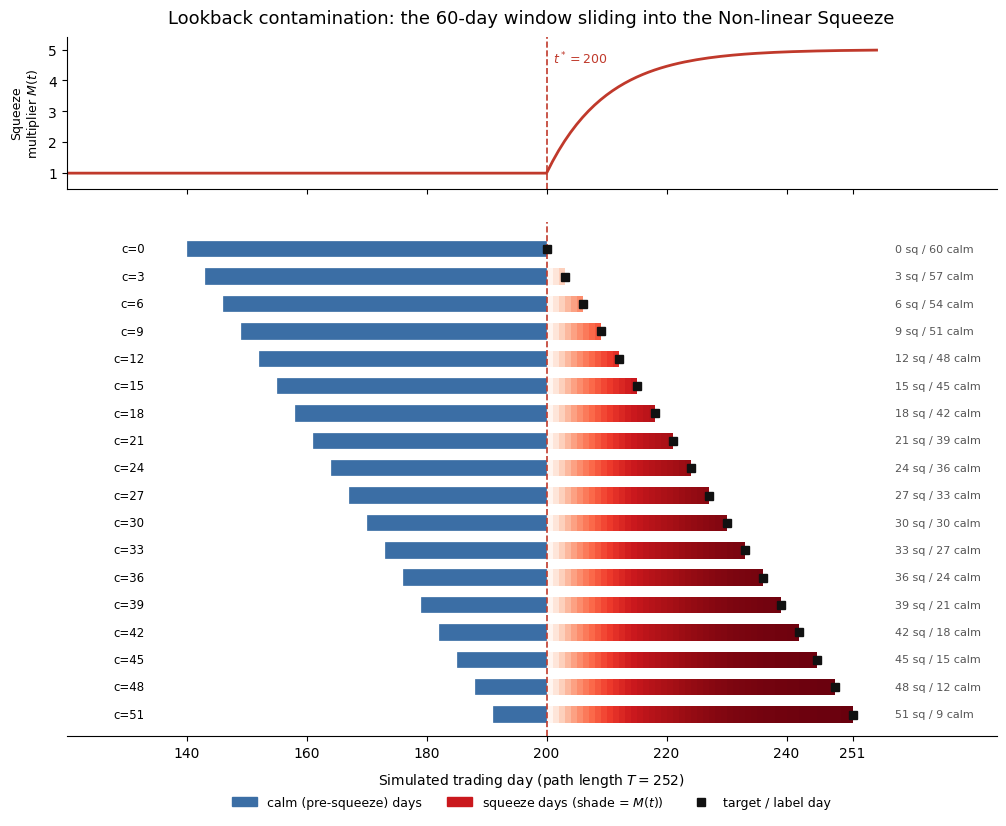

Saved to ../results/contamination_windows.png


<Figure size 640x480 with 0 Axes>

In [27]:
#Construction of the 18 contamination levels
#Non-linear Squeeze multiplier M(t) rising after the onset day t* = 200
#bottom panel draws the 60-day lookback window at each of the 18 contamination levels (c = 0, 3, ..., 51),
#with calm days in blue, squeeze days shaded by their multiplier, and the excluded target day marked. It shows how increasing c swaps calm days for squeeze days inside the fixed-length window.


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from matplotlib import colors, colormaps

#  protocol parameters 
t_star = 200        # squeeze onset day (t*)
L      = 60         # feature-window length
M_max  = 5.0        # asymptotic squeeze multiplier
tau    = 10.0       # squeeze time constant
cs     = list(range(0, 52, 3))   # 18 contamination levels: 0,3,...,51

#  Non-linear Squeeze multiplier M(t) 
def M(t):
    t = np.asarray(t, dtype=float)
    return np.where(t < t_star, 1.0,
                    1 + (M_max - 1) * (1 - np.exp(-(t - t_star) / tau)))

#  figure: top panel = M(t), bottom panel = sliding windows 
fig, (ax_top, ax) = plt.subplots(
    2, 1, figsize=(12, 9.2), sharex=True,
    gridspec_kw={"height_ratios": [1, 3.4], "hspace": 0.10})

# top: the exponential squeeze multiplier
days = np.arange(120, 256)
ax_top.plot(days, M(days), color="#c0392b", lw=2)
ax_top.axvline(t_star, color="#c0392b", ls="--", lw=1.2)
ax_top.text(t_star + 1, 5.0, r"$t^*=200$", color="#c0392b", fontsize=9, va="top")
ax_top.set_ylabel("Squeeze\nmultiplier $M(t)$", fontsize=9)
ax_top.set_ylim(0.5, 5.4)
ax_top.set_title("Lookback contamination: the 60-day window sliding into the "
                 "Non-linear Squeeze", fontsize=13, pad=10)
for s in ["top", "right"]:
    ax_top.spines[s].set_visible(False)

# bottom: one horizontal bar per contamination level
norm = colors.Normalize(vmin=1.0, vmax=M_max)
reds = colormaps["Reds"]
pre_col, tgt_col = "#3b6ea5", "#111111"

for i, c in enumerate(cs):
    y        = len(cs) - i          # c=0 at top
    t_start  = t_star + c - L       # window start = 140 + c
    win_last = t_star + c - 1       # last day inside the window = 199 + c
    t_end    = t_star + c           # target/label day (excluded) = 200 + c

    # calm (pre-squeeze) portion
    pre_end = min(win_last, t_star - 1)
    if pre_end >= t_start:
        ax.barh(y, pre_end - t_start + 1, left=t_start, height=0.6,
                color=pre_col, edgecolor="white", linewidth=0.2)

    # squeeze portion, each day shaded by its multiplier M(t)
    for d in range(max(t_start, t_star), win_last + 1):
        ax.barh(y, 1, left=d, height=0.6,
                color=reds(norm(float(M(d)))), edgecolor="none")

    # target/label day marker
    ax.plot(t_end, y, marker="s", color=tgt_col, markersize=5.5, zorder=5)

    # row labels
    ax.text(133, y, f"c={c}", va="center", ha="right", fontsize=8.5)
    ax.text(258, y, f"{c} sq / {L - c} calm", va="center", ha="left",
            fontsize=8, color="#555")

ax.axvline(t_star, color="#c0392b", ls="--", lw=1.2)
ax.set_xlim(120, 275)
ax.set_ylim(0.2, len(cs) + 1.0)
ax.set_yticks([])
ax.set_xlabel("Simulated trading day (path length $T = 252$)", labelpad=8)
ax.set_xticks([140, 160, 180, 200, 220, 240, 251])
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

handles = [
    Patch(color=pre_col, label="calm (pre-squeeze) days"),
    Patch(color=reds(0.75), label="squeeze days (shade = $M(t)$)"),
    mlines.Line2D([], [], color=tgt_col, marker="s", linestyle="None",
                  markersize=6, label="target / label day"),
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.09),
          ncol=3, frameon=False, fontsize=9)



In [25]:
plt.savefig('../results/contamination_windows.png', dpi=150, bbox_inches='tight')
print("Saved to ../results/contamination_windows.png")

Saved to ../results/contamination_windows.png


<Figure size 640x480 with 0 Axes>

In [24]:
import pandas as pd

t_star, L = 200, 60
rows = []
for c in range(0, 52, 3):
    rows.append({
        "c": c,
        "window_start": t_star + c - L,     # 140 + c
        "window_end":   t_star + c - 1,     # 199 + c  (last day in window)
        "target_day":   t_star + c,         # 200 + c  (label day, excluded)
        "squeeze_days": c,
        "calm_days":    L - c,
    })

contamination_windows = pd.DataFrame(rows)
contamination_windows.to_csv('../results/contamination_windows.csv', index=False)
print("Saved to ../results/contamination_windows.csv")

Saved to ../results/contamination_windows.csv
